EN3160 Assignment 01<br>
Intensity Transformations and Neighborhood Filtering<br>
Name: Gunasekara H.M<br>
Index Number: 230208C<br>
GitHub: https://github.com/Hasindu-UoM/image-processing-project

Question 1

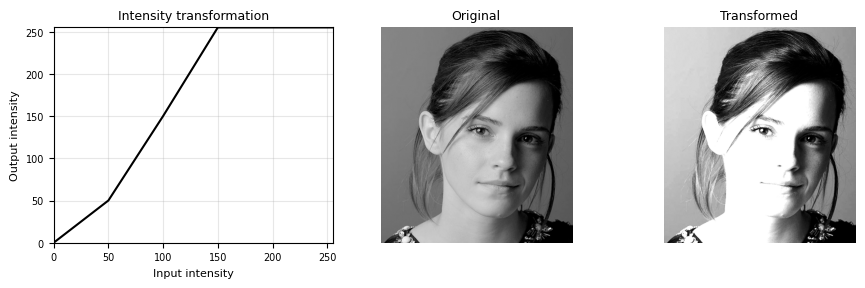

In [25]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv.imread("images/emma.png", cv.IMREAD_GRAYSCALE)
assert img is not None, "Image could not be loaded"

# Breakpoints used for Q1
breakpoints = np.array([
    [0,   0],
    [50,  50],
    [100, 150],
    [150, 255],
    [255, 255]
])

# Piecewise-linear intensity transformation
def intensity_transform(im, breakpoints):
    x = breakpoints[:, 0]
    y = breakpoints[:, 1]

    # Create lookup table using linear interpolation
    lut = np.interp(np.arange(256), x, y)

    # Apply transformation
    transformed = lut[im].astype(np.uint8)

    return transformed

# Apply transformation
transformed = intensity_transform(img, breakpoints)

# -------------------------------------------------
# Display transformation + original + transformed
# -------------------------------------------------

fig, ax = plt.subplots(1, 3, figsize=(9, 2.8))

# Intensity transformation
ax[0].plot(breakpoints[:, 0], breakpoints[:, 1], '-k', linewidth=1.5)
ax[0].set_title("Intensity transformation", fontsize=9)
ax[0].set_xlabel("Input intensity", fontsize=8)
ax[0].set_ylabel("Output intensity", fontsize=8)
ax[0].set_xlim(0, 255)
ax[0].set_ylim(0, 255)
ax[0].grid(True, alpha=0.3)
ax[0].tick_params(labelsize=7)

# Original image
ax[1].imshow(img, cmap="gray", vmin=0, vmax=255)
ax[1].set_title("Original", fontsize=9)
ax[1].axis("off")

# Transformed image
ax[2].imshow(transformed, cmap="gray", vmin=0, vmax=255)
ax[2].set_title("Transformed", fontsize=9)
ax[2].axis("off")

plt.tight_layout(pad=0.4)
plt.show()

The piecewise intensity transformation maps each input intensity to a new
output intensity using the selected breakpoints. The intensity ranges of
greater interest were expanded, while other ranges were compressed.
Different breakpoint combinations were tested and the final set was selected
based on the visual contrast and visibility of details in the transformed
image.

Question 2 

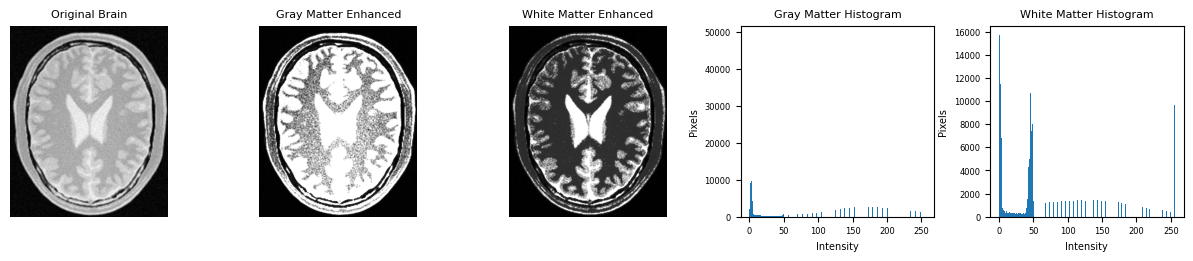

In [27]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load brain image
brain = cv.imread("images/brain.png", cv.IMREAD_GRAYSCALE)
assert brain is not None, "Brain image could not be loaded"

# Piecewise intensity transformation
def piecewise_transform(image, r1, r2, s1, s2):
    output = np.zeros_like(image, dtype=np.uint8)

    mask1 = image <= r1
    output[mask1] = (s1 / r1) * image[mask1]

    mask2 = (image > r1) & (image <= r2)
    output[mask2] = s1 + ((s2 - s1) / (r2 - r1)) * (image[mask2] - r1)

    mask3 = image > r2
    output[mask3] = s2 + ((255 - s2) / (255 - r2)) * (image[mask3] - r2)

    return np.clip(output, 0, 255).astype(np.uint8)

# Gray matter: 150–180
gray_enhanced = piecewise_transform(brain, 150, 180, 50, 255)

# White matter: 180–215
white_enhanced = piecewise_transform(brain, 180, 215, 50, 255)

# Display all 5 results in one row
fig, ax = plt.subplots(1, 5, figsize=(12, 2.5))

ax[0].imshow(brain, cmap="gray")
ax[0].set_title("Original Brain", fontsize=8)
ax[0].axis("off")

ax[1].imshow(gray_enhanced, cmap="gray")
ax[1].set_title("Gray Matter Enhanced", fontsize=8)
ax[1].axis("off")

ax[2].imshow(white_enhanced, cmap="gray")
ax[2].set_title("White Matter Enhanced", fontsize=8)
ax[2].axis("off")

ax[3].hist(gray_enhanced.ravel(), bins=256, range=(0, 256))
ax[3].set_title("Gray Matter Histogram", fontsize=8)
ax[3].set_xlabel("Intensity", fontsize=7)
ax[3].set_ylabel("Pixels", fontsize=7)
ax[3].tick_params(labelsize=6)

ax[4].hist(white_enhanced.ravel(), bins=256, range=(0, 256))
ax[4].set_title("White Matter Histogram", fontsize=8)
ax[4].set_xlabel("Intensity", fontsize=7)
ax[4].set_ylabel("Pixels", fontsize=7)
ax[4].tick_params(labelsize=6)

plt.tight_layout(pad=0.3)
plt.show()

The brain proton-density image was analyzed to identify suitable intensity ranges for different brain tissues. Piecewise intensity transformations were applied to enhance the appearance of the white matter and gray matter regions. The transformation functions increase the intensity differences within the selected ranges, making the boundaries between the different tissue regions more distinguishable. Compared with the original image, the transformed images provide better visual separation of the brain tissues and improve the visibility of their internal details. The transformation curves also show how the input intensity values are mapped to new output values to achieve the desired enhancement.

Question 3

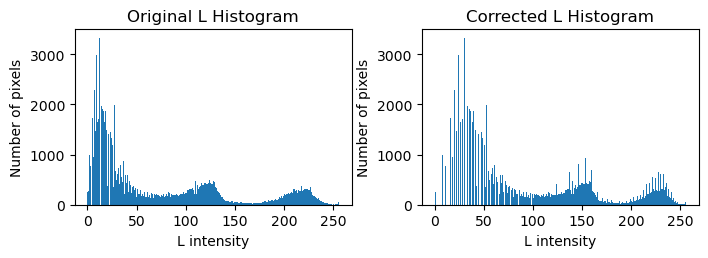

In [28]:
# Load and convert to L*a*b*
img = cv.imread("images/frock.png")
lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
L, a, b = cv.split(lab)

# Gamma correction
gamma = 0.7
L_corr = np.uint8(255 * (L.astype(np.float32) / 255) ** gamma)

# Plot both histograms in one row
fig, ax = plt.subplots(1, 2, figsize=(7, 2.5))

ax[0].hist(L.ravel(), bins=256, range=(0,256))
ax[0].set(title="Original L Histogram", xlabel="L intensity", ylabel="Number of pixels")

ax[1].hist(L_corr.ravel(), bins=256, range=(0,256))
ax[1].set(title="Corrected L Histogram", xlabel="L intensity", ylabel="Number of pixels")

plt.tight_layout(pad=0.4)
plt.show()

Gamma correction was applied to the image using a gamma value of γ = 0.7. Since the gamma value is less than 1, the transformation increases the intensity of darker pixels, making the overall image brighter. This improves the visibility of details in darker regions while preserving the general appearance of the brighter areas. The comparison of the original and corrected L-channel histograms shows that the intensity distribution is shifted towards higher intensity values after gamma correction. Therefore, γ = 0.7 provides improved brightness and visibility compared with the original image.

Question 4

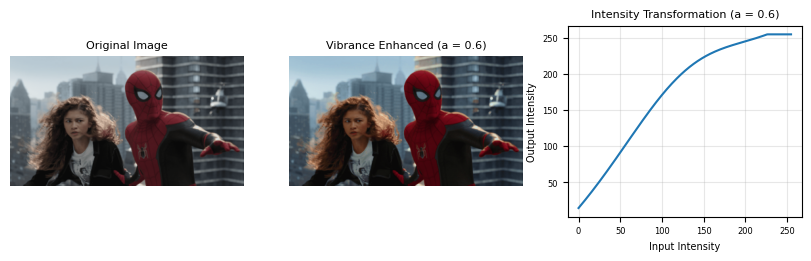

In [29]:
# Load image and convert to HSV
img = cv.imread("images/spider.png")
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv)

# Vibrance transformation (a = 0.6, sigma = 70)
a, sigma = 0.6, 70
x = np.arange(256)
T = np.minimum(x + a*128*np.exp(-(x-128)**2/(2*sigma**2)), 255)
S_new = T[S].astype(np.uint8)

# Recombine HSV and convert to RGB
enhanced = cv.cvtColor(cv.merge([H, S_new, V]), cv.COLOR_HSV2RGB)
original = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Display all three in one row
fig, ax = plt.subplots(1, 3, figsize=(8, 2.5))

ax[0].imshow(original)
ax[0].set_title("Original Image", fontsize=8)
ax[0].axis("off")

ax[1].imshow(enhanced)
ax[1].set_title("Vibrance Enhanced (a = 0.6)", fontsize=8)
ax[1].axis("off")

ax[2].plot(x, T)
ax[2].set_title("Intensity Transformation (a = 0.6)", fontsize=8)
ax[2].set_xlabel("Input Intensity", fontsize=7)
ax[2].set_ylabel("Output Intensity", fontsize=7)
ax[2].tick_params(labelsize=6)
ax[2].grid(True, alpha=0.3)

plt.tight_layout(pad=0.3)
plt.show()

The saturation plane was enhanced using the vibrance transformation, and different values of \(a\) were tested. The value a=0.6 was selected as it provided a noticeable increase in colour vibrance while maintaining a natural appearance. The enhanced image shows more vivid colours compared with the original image.

Question 5 

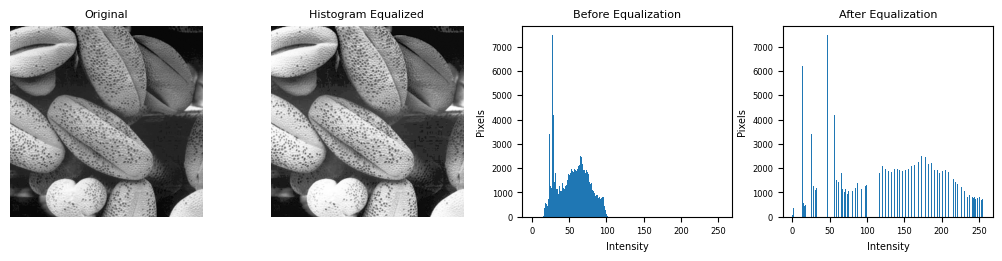

In [30]:
# Load image
img = cv.imread("images/seeds.png", cv.IMREAD_GRAYSCALE)

# Histogram equalization using CDF
hist = np.bincount(img.ravel(), minlength=256)
cdf = np.cumsum(hist)
T = np.round(255 * cdf / img.size).clip(0, 255).astype(np.uint8)
equalized = T[img]

# Display all four results in one row
fig, ax = plt.subplots(1, 4, figsize=(10, 2.5))

ax[0].imshow(img, cmap="gray")
ax[0].set_title("Original", fontsize=8)
ax[0].axis("off")

ax[1].imshow(equalized, cmap="gray")
ax[1].set_title("Histogram Equalized", fontsize=8)
ax[1].axis("off")

ax[2].hist(img.ravel(), bins=256, range=(0,256))
ax[2].set_title("Before Equalization", fontsize=8)
ax[2].set_xlabel("Intensity", fontsize=7)
ax[2].set_ylabel("Pixels", fontsize=7)
ax[2].tick_params(labelsize=6)

ax[3].hist(equalized.ravel(), bins=256, range=(0,256))
ax[3].set_title("After Equalization", fontsize=8)
ax[3].set_xlabel("Intensity", fontsize=7)
ax[3].set_ylabel("Pixels", fontsize=7)
ax[3].tick_params(labelsize=6)

plt.tight_layout(pad=0.3)
plt.show()

Before histogram equalization, the image intensities are mainly concentrated within a limited range, resulting in relatively low contrast and some details being less visible. Histogram equalization redistributes the intensity values across a wider range of the available 0–255 levels. This increases the contrast between different regions of the image and improves the visibility of details. The equalized histogram is therefore more spread across the intensity range compared with the original histogram.

Question 6 

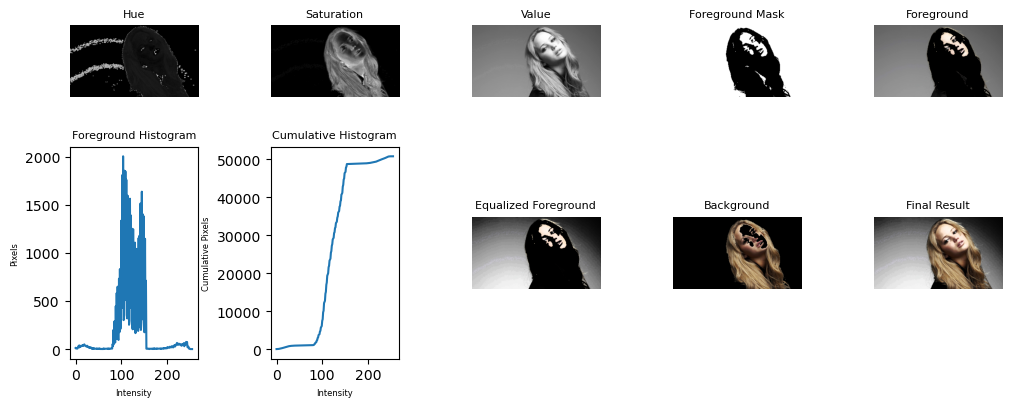

In [32]:
# Load image and HSV conversion
img = cv.imread("images/jeniffer.png")
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv)

# Otsu threshold on Saturation
_, mask = cv.threshold(S, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
mask = cv.bitwise_not(mask)

# Foreground and histogram
foreground = cv.bitwise_and(img, img, mask=mask)
gray_fg = cv.cvtColor(foreground, cv.COLOR_BGR2GRAY)
hist = cv.calcHist([gray_fg], [0], mask, [256], [0, 256]).flatten()
cdf = np.cumsum(hist)

# Histogram equalization of foreground V channel
T = np.clip(255 * cdf / np.count_nonzero(mask), 0, 255).astype(np.uint8)
V_eq = V.copy()
V_eq[mask > 0] = T[V[mask > 0]]

# Equalized foreground
eq_hsv = cv.merge([H, S, V_eq])
eq_fg = cv.cvtColor(eq_hsv, cv.COLOR_HSV2BGR)
eq_fg = cv.bitwise_and(eq_fg, eq_fg, mask=mask)

# Background
bg_mask = cv.bitwise_not(mask)
background = cv.bitwise_and(img, img, mask=bg_mask)

# Final image
final = cv.add(eq_fg, background)

# -------------------------------------------------
# Compact display: 10 results in 2 rows
# -------------------------------------------------
fig, ax = plt.subplots(2, 5, figsize=(10, 4.5))

# Row 1
ax[0,0].imshow(H, cmap="gray")
ax[0,0].set_title("Hue", fontsize=8)

ax[0,1].imshow(S, cmap="gray")
ax[0,1].set_title("Saturation", fontsize=8)

ax[0,2].imshow(V, cmap="gray")
ax[0,2].set_title("Value", fontsize=8)

ax[0,3].imshow(mask, cmap="gray")
ax[0,3].set_title("Foreground Mask", fontsize=8)

ax[0,4].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
ax[0,4].set_title("Foreground", fontsize=8)

# Row 2
ax[1,0].plot(hist)
ax[1,0].set_title("Foreground Histogram", fontsize=8)
ax[1,0].set_xlabel("Intensity", fontsize=6)
ax[1,0].set_ylabel("Pixels", fontsize=6)

ax[1,1].plot(cdf)
ax[1,1].set_title("Cumulative Histogram", fontsize=8)
ax[1,1].set_xlabel("Intensity", fontsize=6)
ax[1,1].set_ylabel("Cumulative Pixels", fontsize=6)

ax[1,2].imshow(cv.cvtColor(eq_fg, cv.COLOR_BGR2RGB))
ax[1,2].set_title("Equalized Foreground", fontsize=8)

ax[1,3].imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB))
ax[1,3].set_title("Background", fontsize=8)

ax[1,4].imshow(cv.cvtColor(final, cv.COLOR_BGR2RGB))
ax[1,4].set_title("Final Result", fontsize=8)

# Remove axes from images
for a in ax.flat:
    if a not in [ax[1,0], ax[1,1]]:
        a.axis("off")

plt.tight_layout(pad=0.3)
plt.show()

The image was converted into the HSV colour space, and the Hue, Saturation, and Value planes were examined. The Saturation plane was selected for thresholding because it provided a clear separation between the foreground and background. A binary mask was generated to extract the foreground using cv.bitwise_and(). The histogram and cumulative distribution function of the foreground were then calculated, and histogram equalization was applied only to the foreground region. Finally, the equalized foreground was combined with the original background. This enhanced the contrast and visibility of details in the foreground while keeping the background largely unchanged.

Question 7 

In [ ]:
img7 = cv.imread(
    "images/einstein.png",
    cv.IMREAD_GRAYSCALE
)

assert img7 is not None

In [ ]:
sobel_x = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

sobel_y = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
])

im_x = cv.filter2D(
    img7,
    cv.CV_64F,
    sobel_x
)

im_y = cv.filter2D(
    img7,
    cv.CV_64F,
    sobel_y
)

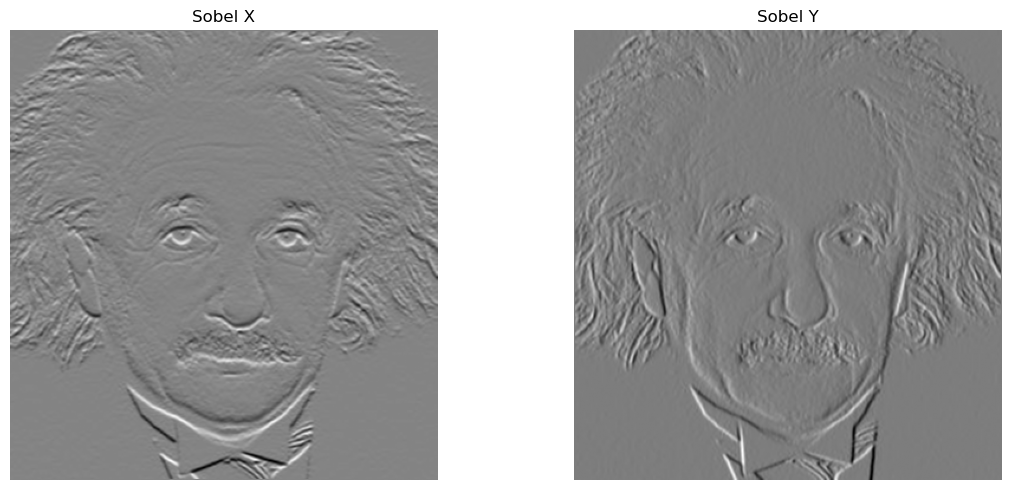

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(im_x, cmap="gray")
ax[0].set_title("Sobel X")
ax[0].axis("off")

ax[1].imshow(im_y, cmap="gray")
ax[1].set_title("Sobel Y")
ax[1].axis("off")

plt.tight_layout()
plt.show()

The Sobel operator was applied to the image in both the horizontal (Sobel Y) and vertical (Sobel X) directions. The Sobel X result emphasizes vertical edges by detecting intensity changes in the horizontal direction, while the Sobel Y result emphasizes horizontal edges by detecting intensity changes in the vertical direction. The resulting images clearly highlight the corresponding edges and demonstrate the effectiveness of Sobel filtering for edge detection.

# Question 8 

Implement image zooming using nearest-neighbor and bilinear interpolation, and compare the results using normalized SSD.

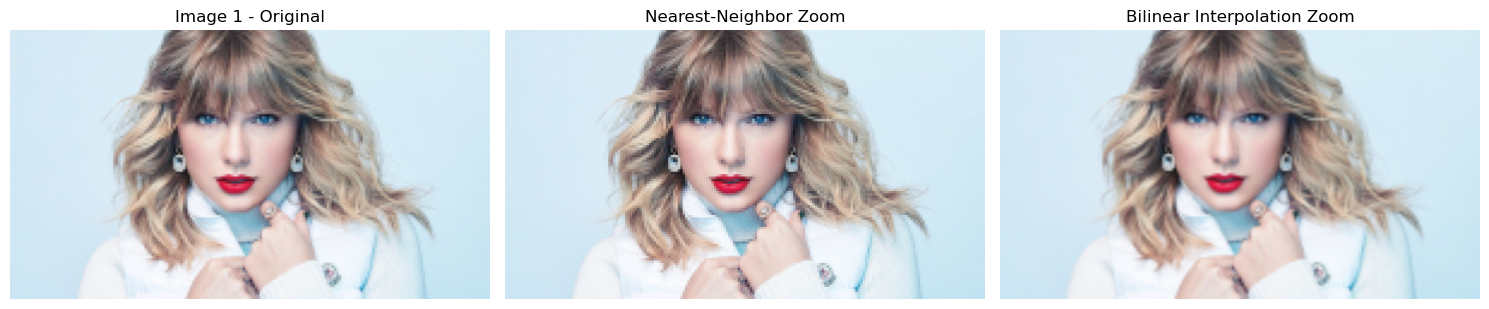

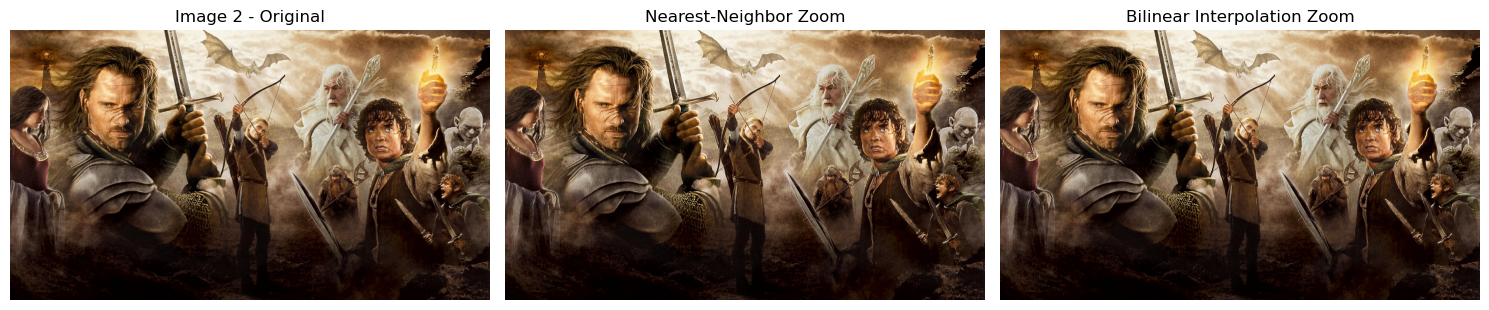

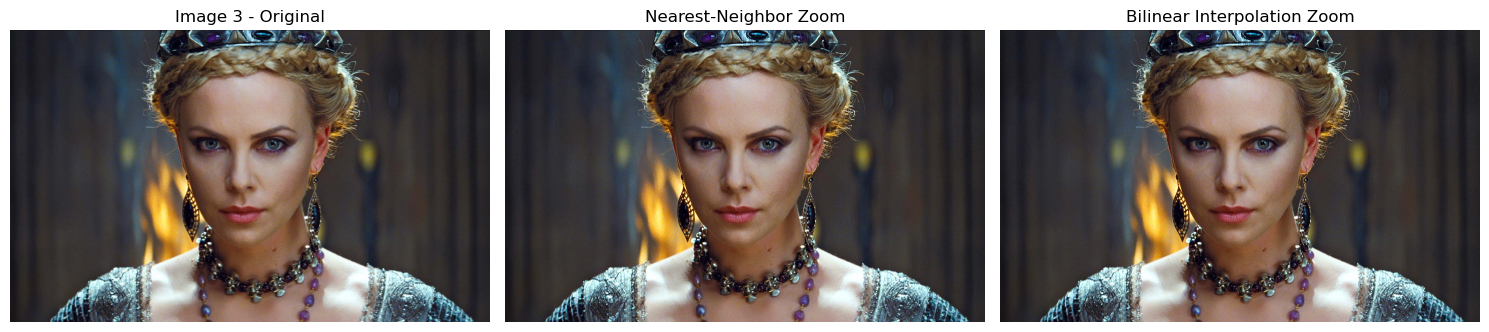

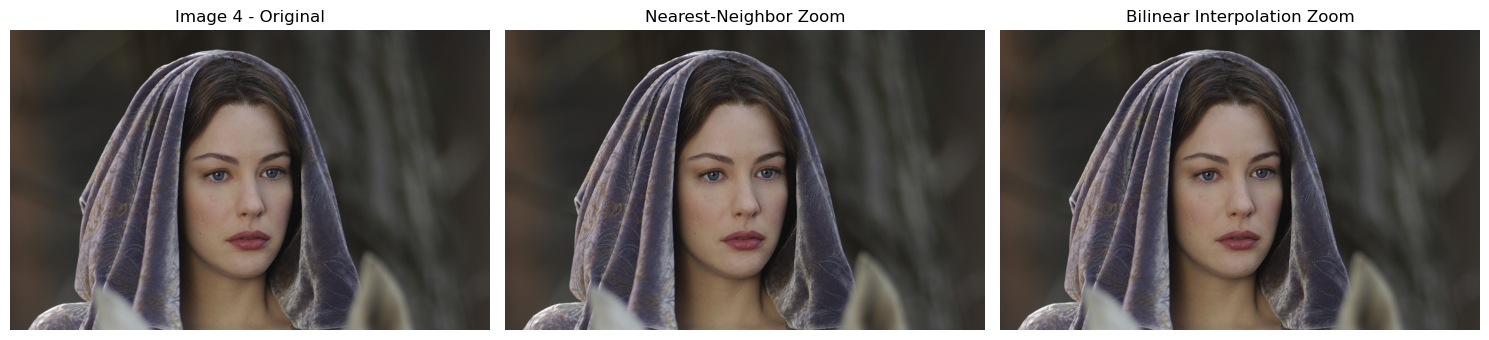

In [22]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Q8 - Image Zooming
# ============================================================

# Nearest-neighbor interpolation
def nearest_neighbor_zoom(image, zoom_factor):

    height, width = image.shape[:2]

    new_height = int(height * zoom_factor)
    new_width = int(width * zoom_factor)

    # Map output coordinates to original coordinates
    x = (np.arange(new_height) / zoom_factor).astype(int)
    y = (np.arange(new_width) / zoom_factor).astype(int)

    # Nearest-neighbor mapping
    zoomed_image = image[x[:, None], y[None, :]]

    return zoomed_image


# Bilinear interpolation
def bilinear_zoom(image, zoom_factor):

    height, width = image.shape[:2]

    new_height = int(height * zoom_factor)
    new_width = int(width * zoom_factor)

    # Coordinates in original image
    x = np.arange(new_height) / zoom_factor
    y = np.arange(new_width) / zoom_factor

    # Four neighboring pixel coordinates
    x1 = np.floor(x).astype(int)
    y1 = np.floor(y).astype(int)

    x2 = np.minimum(x1 + 1, height - 1)
    y2 = np.minimum(y1 + 1, width - 1)

    # Fractional parts
    dx = x - x1
    dy = y - y1

    # Get four neighboring pixels
    I11 = image[x1[:, None], y1[None, :]].astype(np.float32)
    I21 = image[x2[:, None], y1[None, :]].astype(np.float32)
    I12 = image[x1[:, None], y2[None, :]].astype(np.float32)
    I22 = image[x2[:, None], y2[None, :]].astype(np.float32)

    # Reshape weights for RGB channels
    dx = dx[:, None, None]
    dy = dy[None, :, None]

    # Bilinear interpolation
    zoomed_image = (
        I11 * (1 - dx) * (1 - dy) +
        I21 * dx * (1 - dy) +
        I12 * (1 - dx) * dy +
        I22 * dx * dy
    )

    return np.clip(zoomed_image, 0, 255).astype(np.uint8)


# ============================================================
# Read the four images
# ============================================================

img1 = cv.imread("images/taylor.jpg")
img2 = cv.imread("images/rings.png")
img3 = cv.imread("images/snow.png")
img4 = cv.imread("images/arewan.png")

assert img1 is not None, "taylor.jpg not found"
assert img2 is not None, "rings.png not found"
assert img3 is not None, "snow.png not found"
assert img4 is not None, "arewan.png not found"


images = [img1, img2, img3, img4]

# Zoom factor required for Q8
zoom_factor = 4.0


# ============================================================
# Zoom and display all four images
# ============================================================

for i, img in enumerate(images, 1):

    nearest = nearest_neighbor_zoom(img, zoom_factor)
    bilinear = bilinear_zoom(img, zoom_factor)

    plt.figure(figsize=(15, 4))

    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(f"Image {i} - Original")
    plt.axis("off")

    # Nearest-neighbor
    plt.subplot(1, 3, 2)
    plt.imshow(cv.cvtColor(nearest, cv.COLOR_BGR2RGB))
    plt.title("Nearest-Neighbor Zoom")
    plt.axis("off")

    # Bilinear
    plt.subplot(1, 3, 3)
    plt.imshow(cv.cvtColor(bilinear, cv.COLOR_BGR2RGB))
    plt.title("Bilinear Interpolation Zoom")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

The images were zoomed by a factor of 4 using nearest-neighbor and bilinear interpolation methods. Nearest-neighbor interpolation assigns each new pixel the value of the closest original pixel, resulting in sharper but more blocky images. In contrast, bilinear interpolation calculates new pixel values using the neighbouring pixels, producing smoother and more visually natural results. The normalized SSD can be used to quantitatively compare the reconstructed images, with a lower SSD indicating a smaller difference from the reference image. Overall, bilinear interpolation provides better visual quality by reducing the blocky appearance produced by nearest-neighbor interpolation.

Question 9 

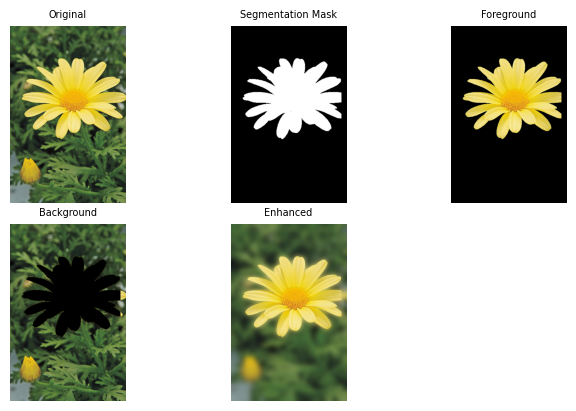

In [36]:
img = cv.imread("images/flower.png")
rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# GrabCut
mask = np.zeros(img.shape[:2], np.uint8)
bg = np.zeros((1,65), np.float64)
fg = np.zeros((1,65), np.float64)

cv.grabCut(img, mask, (20,70,320,300), bg, fg, 5, cv.GC_INIT_WITH_RECT)
mask = np.where((mask==1)|(mask==3), 1, 0).astype(np.uint8)

# Foreground, background and enhanced image
foreground = img * mask[:,:,None]
background = img * (1-mask[:,:,None])
blurred = cv.GaussianBlur(img, (51,51), 0)
enhanced = np.where(mask[:,:,None], img, blurred)

images = [
    (rgb, "Original"),
    (mask, "Segmentation Mask"),
    (cv.cvtColor(foreground, cv.COLOR_BGR2RGB), "Foreground"),
    (cv.cvtColor(background, cv.COLOR_BGR2RGB), "Background"),
    (cv.cvtColor(enhanced, cv.COLOR_BGR2RGB), "Enhanced")
]

# 2 rows × 3 columns
plt.figure(figsize=(7, 4))

for i, (im, title) in enumerate(images):
    plt.subplot(2, 3, i+1)
    plt.imshow(im, cmap="gray" if i == 1 else None)
    plt.title(title, fontsize=7)
    plt.axis("off")

plt.tight_layout(pad=0.3)
plt.show()

Discussion

The dark region just beyond the edge of the flower is caused by the
segmentation mask and the blurring operation. Pixels belonging to the
foreground are separated from the background using the binary mask.
When the background is blurred near the boundary of the flower, pixels
from different regions are averaged together. If the foreground
background separation contains dark or zero-valued pixels near the
boundary, these pixels contribute to the Gaussian averaging process.
As a result, the background immediately surrounding the flower can
appear darker than the original image.

Question 10 

MSE: 4405.177782703923


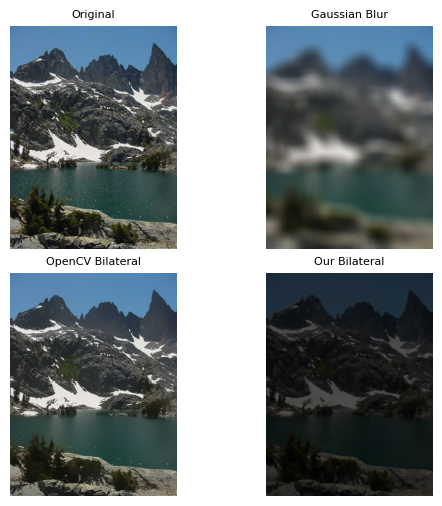

In [37]:
# Load image
img = cv.imread("images/mountain.png")
rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Gaussian and OpenCV bilateral
gaussian = cv.GaussianBlur(img, (31,31), 15)
bilateral_cv = cv.bilateralFilter(img, 0, 50, 15)

# Own bilateral filter
def my_bilateral(im, ss=15, sr=50, k=5):
    r = k//2
    p = cv.copyMakeBorder(im.astype(np.float64), r,r,r,r,cv.BORDER_REFLECT)
    out = np.zeros_like(im, dtype=np.float64)

    x,y = np.meshgrid(np.arange(-r,r+1), np.arange(-r,r+1))
    spatial = np.exp(-(x*x+y*y)/(2*ss*ss))

    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            n = p[i:i+k, j:j+k]
            diff = n - p[i+r,j+r]
            range_w = np.exp(-(diff**2)/(2*sr**2))
            w = spatial[:,:,None] * range_w
            out[i,j] = np.sum(w*n, axis=(0,1)) / np.sum(w)

    return np.clip(out,0,255).astype(np.uint8)

bilateral_own = my_bilateral(img)

# MSE
mse = np.mean((bilateral_cv.astype(float) -
               bilateral_own.astype(float))**2)
print("MSE:", mse)

# Display all results - small, 2×2
results = [
    (rgb, "Original"),
    (cv.cvtColor(gaussian, cv.COLOR_BGR2RGB), "Gaussian Blur"),
    (cv.cvtColor(bilateral_cv, cv.COLOR_BGR2RGB), "OpenCV Bilateral"),
    (cv.cvtColor(bilateral_own, cv.COLOR_BGR2RGB), "Our Bilateral")
]

plt.figure(figsize=(6, 5))

for i, (im, title) in enumerate(results):
    plt.subplot(2, 2, i+1)
    plt.imshow(im)
    plt.title(title, fontsize=8)
    plt.axis("off")

plt.tight_layout(pad=0.5)
plt.show()

Bilateral filtering was applied to the Lake Minaret image using both the OpenCV implementation and a manually implemented bilateral filter. Unlike Gaussian filtering, bilateral filtering considers both spatial distance and intensity similarity, allowing noise to be reduced while preserving important edges. The Gaussian-filtered image appears smoother but tends to blur edges, whereas the bilateral-filtered image maintains sharper boundaries and important details. The output of the custom bilateral filter was also compared with the OpenCV result using the Mean Squared Error (MSE). A lower MSE indicates that the custom implementation produces an output closer to the OpenCV bilateral filtering result.